### Test based on the documentation
See https://virtualfleet.readthedocs.io/en/latest/usage/preparation.html

In [1]:
import numpy as np
from datetime import timedelta
from virtualargofleet import Velocity, FloatConfiguration, VirtualFleet

In [2]:
# Number of floats we want to simulate:
nfloats = 5

# Define space/time locations of deployments:
lat = np.linspace(37, 42, nfloats)
lon = np.full_like(lat, 6)
tim = np.array(['2026-01-01' for i in range(nfloats)], dtype='datetime64')

# Define the deployment plan as a dictionary:
my_plan = {'lat': lat, 'lon': lon, 'time': tim}

In [3]:
# Check file
file = "./data/cmems_mod_med_phy-cur_anfc_4.2km_P1D-m.nc"
import xarray as xr
ds = xr.load_dataset(file)
ds

<xarray.Dataset> Size: 292MB
Dimensions:    (time: 5, depth: 141, latitude: 216, longitude: 240)
Coordinates:
  * time       (time) datetime64[ns] 40B 2026-01-01 2026-01-02 ... 2026-01-05
  * depth      (depth) float32 564B 1.018 3.166 5.465 ... 5.646e+03 5.754e+03
  * latitude   (latitude) float32 864B 36.02 36.06 36.1 ... 44.9 44.94 44.98
  * longitude  (longitude) float32 960B 1.456e-06 0.04167 ... 9.917 9.958
Data variables:
    uo         (time, depth, latitude, longitude) float32 146MB 0.1138 ... nan
    vo         (time, depth, latitude, longitude) float32 146MB 0.06589 ... nan
Attributes:
    Conventions:       CF-1.11
    title:             Horizontal Velocity (3D) - Daily Mean
    institution:       Centro Euro-Mediterraneo sui Cambiamenti Climatici - C...
    source:            MedFS EAS10
    contact:           servicedesk.cmems@mercator-ocean.eu
    references:        Please check in CMEMS catalogue the INFO section for p...
    comment:           Please check in CMEMS catalogue the INFO section for p...
    subset:source:     ARCO data downloaded from the Marine Data Store using ...
    subset:productId:  MEDSEA_ANALYSISFORECAST_PHY_006_013
    subset:datasetId:  cmems_mod_med_phy-cur_anfc_4.2km_P1D-m_202511
    subset:date:       2026-08-12T10:13:31.567Z

In [4]:
root = "./data/"
#file = "cmems_mod_glo_phy_anfc_0.083_deg_PT1h-m.nc"
file = "cmems_mod_med_phy-cur_anfc_4.2km_P1D-m.nc"
filenames = {'U': root + file,
              'V': root + file}
variables = {'U':'uo', 'V':'vo'}
dimensions = {'time': 'time', 'depth':'depth', 'lat': 'latitude', 'lon': 'longitude'}
VELfield = Velocity(model='custom',
                    src=filenames,
                    variables=variables,
                    dimensions=dimensions)

In [5]:
#cfg = FloatConfiguration('default') # Does not work
cfg = FloatConfiguration(root + "my_config.json")

In [6]:
VFleet = VirtualFleet(plan=my_plan, fieldset=VELfield, mission=cfg)

In [9]:
VFleet

<VirtualFleet>
- 5 floats in the deployment plan
- No simulation performed

In [11]:
VFleet.simulate(duration=timedelta(days=5))

A simulation has already been performed with this VirtualFleet
/Users/flo/Downloads/VirtualFleet/virtualargofleet/virtualargofleet.py:361: UserWarning: Simulation will be saved in : ./_sh331f7.zarr
  warnings.warn(output_msg)


INFO: Output files are stored in ./_sh331f7.zarr.
  3%|▉                           | 14700.0/432000.0 [00:00<00:06, 60132.54it/s]

/Users/flo/Work/VirtualFleet_webapp/.venv/lib/python3.11/site-packages/parcels/particledata.py:358: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  np.less_equal(time - np.abs(pd["dt"] / 2), pd["time"], where=np.isfinite(pd["time"]))
/Users/flo/Work/VirtualFleet_webapp/.venv/lib/python3.11/site-packages/parcels/particledata.py:359: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  & np.greater_equal(time + np.abs(pd["dt"] / 2), pd["time"], where=np.isfinite(pd["time"]))
/Users/flo/Work/VirtualFleet_webapp/.venv/lib/python3.11/site-packages/parcels/particledata.py:360: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  | ((np.isnan(pd["dt"])) & np.equal(time, pd["time"], where=np.isfinite(pd["time"])))


 24%|██████▎                   | 104400.0/432000.0 [00:01<00:02, 115240.40it/s]

/Users/flo/Work/VirtualFleet_webapp/.venv/lib/python3.11/site-packages/parcels/particledata.py:358: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  np.less_equal(time - np.abs(pd["dt"] / 2), pd["time"], where=np.isfinite(pd["time"]))
/Users/flo/Work/VirtualFleet_webapp/.venv/lib/python3.11/site-packages/parcels/particledata.py:359: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  & np.greater_equal(time + np.abs(pd["dt"] / 2), pd["time"], where=np.isfinite(pd["time"]))
/Users/flo/Work/VirtualFleet_webapp/.venv/lib/python3.11/site-packages/parcels/particledata.py:360: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  | ((np.isnan(pd["dt"])) & np.equal(time, pd["time"], where=np.isfinite(pd["time"])))


...

/Users/flo/Work/VirtualFleet_webapp/.venv/lib/python3.11/site-packages/parcels/particledata.py:358: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  np.less_equal(time - np.abs(pd["dt"] / 2), pd["time"], where=np.isfinite(pd["time"]))
/Users/flo/Work/VirtualFleet_webapp/.venv/lib/python3.11/site-packages/parcels/particledata.py:359: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  & np.greater_equal(time + np.abs(pd["dt"] / 2), pd["time"], where=np.isfinite(pd["time"]))
/Users/flo/Work/VirtualFleet_webapp/.venv/lib/python3.11/site-packages/parcels/particledata.py:360: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  | ((np.isnan(pd["dt"])) & np.equal(time, pd["time"], where=np.isfinite(pd["time"])))


 64%|████████████████▋         | 277200.0/432000.0 [00:02<00:01, 107540.61it/s]

/Users/flo/Work/VirtualFleet_webapp/.venv/lib/python3.11/site-packages/parcels/particledata.py:358: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  np.less_equal(time - np.abs(pd["dt"] / 2), pd["time"], where=np.isfinite(pd["time"]))
/Users/flo/Work/VirtualFleet_webapp/.venv/lib/python3.11/site-packages/parcels/particledata.py:359: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  & np.greater_equal(time + np.abs(pd["dt"] / 2), pd["time"], where=np.isfinite(pd["time"]))
/Users/flo/Work/VirtualFleet_webapp/.venv/lib/python3.11/site-packages/parcels/particledata.py:360: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  | ((np.isnan(pd["dt"])) & np.equal(time, pd["time"], where=np.isfinite(pd["time"])))


100%|██████████████████████████| 432000.0/432000.0 [00:03<00:00, 114379.31it/s]


<VirtualFleet>
- 5 floats in the deployment plan
- Number of simulation(s): 2
- Last simulation meta-data:
	- Duration: 05d 00h 00m 00s
	- Data recording every: 01h 00m
	- Trajectory file: ./_sh331f7.zarr
	- Execution time: 00d 00h 00m 04s
	- Executed on: Mac

In [12]:
VFleet

<VirtualFleet>
- 5 floats in the deployment plan
- Number of simulation(s): 2
- Last simulation meta-data:
	- Duration: 05d 00h 00m 00s
	- Data recording every: 01h 00m
	- Trajectory file: ./_sh331f7.zarr
	- Execution time: 00d 00h 00m 04s
	- Executed on: Mac

In [13]:
ds = xr.open_zarr(VFleet.output)

In [14]:
ds

<xarray.Dataset> Size: 25kB
Dimensions:       (trajectory: 5, obs: 120)
Coordinates:
  * trajectory    (trajectory) int64 40B 10 11 12 13 14
  * obs           (obs) int32 480B 0 1 2 3 4 5 6 ... 113 114 115 116 117 118 119
Data variables:
    cycle_age     (trajectory, obs) float32 2kB dask.array<chunksize=(5, 1), meta=np.ndarray>
    cycle_number  (trajectory, obs) float64 5kB dask.array<chunksize=(5, 1), meta=np.ndarray>
    cycle_phase   (trajectory, obs) float64 5kB dask.array<chunksize=(5, 1), meta=np.ndarray>
    lat           (trajectory, obs) float32 2kB dask.array<chunksize=(5, 1), meta=np.ndarray>
    lon           (trajectory, obs) float32 2kB dask.array<chunksize=(5, 1), meta=np.ndarray>
    time          (trajectory, obs) datetime64[ns] 5kB dask.array<chunksize=(5, 1), meta=np.ndarray>
    z             (trajectory, obs) float32 2kB dask.array<chunksize=(5, 1), meta=np.ndarray>
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        ArgoParticleArgoFloatKernelAdvectionRK4KeepInWate...
    parcels_mesh:           spherical
    parcels_version:        3.1.4

In [16]:
from matplotlib import pyplot as plt

Matplotlib is building the font cache; this may take a moment.


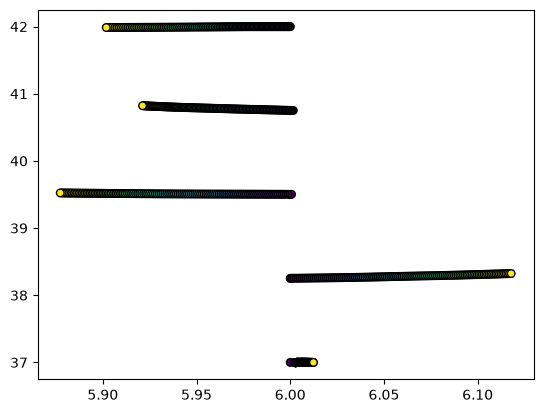

In [18]:
plt.scatter(ds.lon, ds.lat, c=ds.cycle_age, s=30, cmap="viridis", edgecolors="k")